# Model of the LIDA cavity for the beam alignment

A simple geometric model to aid the learning process and analytic calculations.
 - 3x3 matrices for ray alignment vectors $$\begin{pmatrix} x \\ \theta_x \\ 1 \end{pmatrix},~~~\begin{pmatrix} y \\ \theta_y \\ 1 \end{pmatrix} $$
 - standard ABCD matrices for the Gaussian beam parameter tracking $$q' = \frac{Aq+B}{Cq+d}$$
 - Astigmatic beams: $$ I=|u|^2 = \frac{2P}{\pi w_x w_y}\exp\left(-\frac{2x^2}{w_x^2} - \frac{2y^2}{w_y^2}\right)$$
- Layout:
 
![](cavmodel/schematic.png)

- Mirror order:
    - IHR (HR mirror at the input side) -> OHR (curved HR mirror at the output side) -> OC (Output coupler) -> IC (input coupler)
- NOT following the sign conventions from Denis's script in elog [#639](https://lnx0.sr.bham.ac.uk:8081/Dark+Matter/639) (but providing `.denisify()` method to convert the matrices into Denis's convention)
- Sign conventions, yaw:
    - all mirror misalignment angles and ray direction angles are positive if CCW (looking at the cavity from above)
    - all X axes are chosen such that a beam's displacement is positive when it steers towards the inside of the cavity (e.g. towards the left of its primary propagation direction if looking from above).
- Sign conventions, pitch:
    - all ray direction angles are positive if CCW (looking from the side such that the beam propagates from the left to the right)
    - all Y axes are chosen such that a beam's displacement is positive when it steers upwards.

# Usage example

Original images of the mirrors:


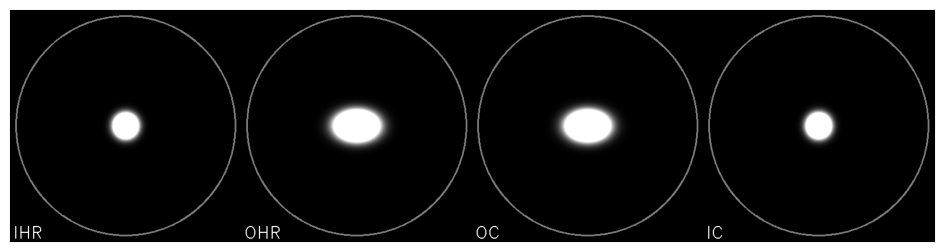

Transfer matrix, mirrors' yaw -> beam x-position at the mirrors (in m/rad):
[[ 2.2145 -7.2125  7.1145 -2.3125]
 [-7.2125  7.2125 -7.2125  7.2125]
 [ 7.1145 -7.2125  7.0145 -7.1125]
 [-2.3125  7.2125 -7.1125  2.2125]]

Target X-positions: [[-0.005], [0.007], [0.004], [-0.006]]
Target Y-positions: [[0.004], [-0.006], [-0.004], [0.003]]

New mirror misalignment angles:
    Yaw: [ 0.05479592 -0.05423354 -0.05479592  0.05520408]
    Pitch: [ 0.00602041 -0.01043217  0.00928571 -0.00428571]

Updated images of the mirrors:


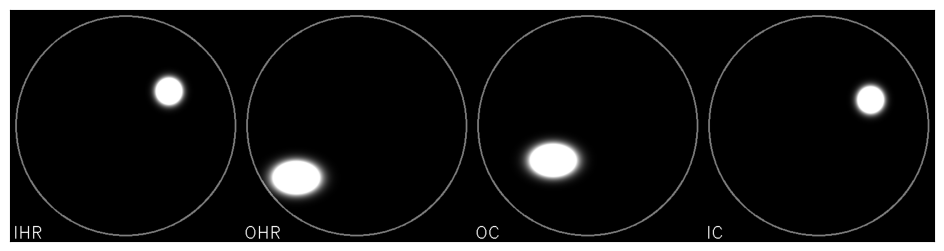

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import cavmodel

mirror_spacings = [0.1, 4.9, 0.1, 4.9]  # Distances between mirrors
radii_of_curvature = [np.inf, 10.2, np.inf, np.inf]  # Mirrors RoCs
mirror_labels = ['IHR', 'OHR', 'OC', 'IC'] # Mirror labels

# initialise the cavity and calculate the transfer matrices
cavity = cavmodel.RectangularCavity(mirror_spacings, radii_of_curvature)

# visualise the beam spots
print('Original images of the mirrors:')
cavity.show_image(labels=mirror_labels)

# print the transfer matrix from mirror misalignments in yaw to the beam positions at the mirrors
print('Transfer matrix, mirrors\' yaw -> beam x-position at the mirrors (in m/rad):')
print(np.array2string(cavity.tm_yaw_to_pos_x,precision=4,suppress_small=True))
# print('Transfer matrix, mirrors\' pitch -> beam y-position at the mirrors (in m/rad):')
# print(np.array2string(cavity.tm_pitch_to_pos_y,precision=4,suppress_small=True))

# set the target beam positions at the mirrors
target_pos_x = [[-5.0e-3], [7.0e-3], [4.0e-3], [-6.0e-3]]
target_pos_y = [[4.0e-3], [-6.0e-3], [-4.0e-3], [3.0e-3]]
print()
print(f"Target X-positions: {target_pos_x}")
print(f"Target Y-positions: {target_pos_y}")

# obtain corresponding mirror misalignment angles
yaw = (cavity.tm_pos_x_to_yaw @ target_pos_x).flatten()
pitch = (cavity.tm_pos_y_to_pitch @ target_pos_y).flatten()
# set the misalignment angles on mirrors
cavity.set_all_yaws_and_pitches(yaw, pitch)

print()
print("New mirror misalignment angles:")
print(f"    Yaw: {yaw}")
print(f"    Pitch: {pitch}")

# visualise the updated beam spots
print()
print("Updated images of the mirrors:")
_ = cavity.show_image(labels=mirror_labels)

In [ ]:
# help(cavmodel.RectangularCavity)
# help(cavmodel.MirrorAt45)
# help(cavmodel.MirrorImage)